# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

## Imports

In [50]:
import pandas as pd  # for loading and working with data
from sklearn.model_selection import train_test_split, GridSearchCV  # for splitting data and tuning hyperparameters
from sklearn.tree import DecisionTreeClassifier  # Decision Tree model
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay  # for evaluation
import matplotlib.pyplot as plt  # for plotting

## Load and Explore the Dataset

In [51]:
# Load the dataset from the CSV file
df = pd.read_csv("data_banknote_authentication.csv")

# Show the first 5 rows to see what the data looks like
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [52]:
# Show info about the dataset (columns, data types, missing values)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


## Train / Test Split

In [53]:
# X = all columns except "Class" (these are the features)
X = df.drop("Class", axis=1)

# y = the "Class" column (this is what we want to predict: 0 = real, 1 = fake)
y = df["Class"]

# Split the data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## Decision Tree with GridSearchCV

In [54]:
# Create a Decision Tree model
dt = DecisionTreeClassifier()

# Define the hyperparameters we want to try
param_grid_dt = {
    "max_depth": [1, 3, 5, 10, None],  # how deep the tree can go (None = no limit)
    "criterion": ["gini", "entropy"]    # the method used to measure split quality
}

# Use GridSearchCV to try all combinations and find the best one (5-fold cross-validation)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

# Print the best combination of hyperparameters
print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10}


### Decision Tree - Evaluation

In [55]:
# Make predictions on the test data using the best Decision Tree
dt_preds = grid_dt.predict(X_test)

In [56]:
# Print the confusion matrix (shows correct vs wrong predictions)
print("Confusion Matrix:")
confusion_matrix(y_test, dt_preds)

Confusion Matrix:


array([[237,   1],
       [  0, 174]])

In [57]:
# Print the classification report (precision, recall, f1-score, accuracy)
print("Classification Report:")
print(classification_report(y_test, dt_preds))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



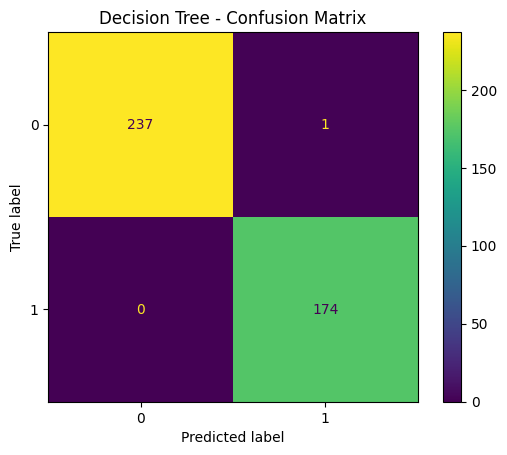

In [58]:
# Plot the confusion matrix as a visual heatmap
ConfusionMatrixDisplay.from_estimator(grid_dt, X_test, y_test)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

## Random Forest with GridSearchCV

In [59]:
# Create a Random Forest model
rf = RandomForestClassifier()

# Define the hyperparameters we want to try
param_grid_rf = {
    "n_estimators": [50, 100, 200],    # number of trees in the forest
    "max_depth": [3, 5, 10, None],     # how deep each tree can go
    "max_features": ["sqrt", "log2"]   # number of features each tree considers per split
}

# Use GridSearchCV to try all combinations and find the best one (5-fold cross-validation)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

# Print the best combination of hyperparameters
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 50}


### Random Forest - Evaluation

In [60]:
# Make predictions on the test data using the best Random Forest
rf_preds = grid_rf.predict(X_test)

In [61]:
# Print the confusion matrix
print("Confusion Matrix:")
confusion_matrix(y_test, rf_preds)

Confusion Matrix:


array([[234,   4],
       [  0, 174]])

In [62]:
# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



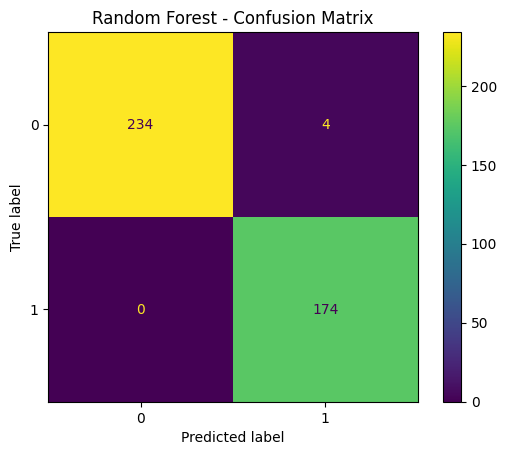

In [63]:
# Plot the confusion matrix as a visual heatmap
ConfusionMatrixDisplay.from_estimator(grid_rf, X_test, y_test)
plt.title("Random Forest - Confusion Matrix")
plt.show()

## Comparison

Both models did very well on this dataset. However, the Decision Tree did slightly better than the Random Forest:

- **Decision Tree:** 99.8% accuracy (only 1 wrong prediction)
- **Random Forest:** 99.0% accuracy  (4 wrong predictions)

I think the Decision Tree did better because the dataset is small and clean, so one well tree was enough to learn the patterns. The Random Forest uses many trees together, which usually helps, but in this case it made a few more mistakes.

For this dataset, the Decision Tree with `criterion='entropy'` and `max_depth=10` gave the best results.